# Dimer Case 2:  Davies-GKSL with the full interaction picture

Since $\omega_{0}$ and $\Omega$ are much larger than $\gamma_{0}$, we eliminate $\omega_{0}$ and $\Omega$ from the Hamiltonian using the full interaction picture. 

In [1]:
%run dimer-case2-functions.ipynb

In [2]:
# parameter values
omega0 = 1
gamma0 = 1.e-8*omega0
T = 0.86*omega0
chi = np.pi/2
k0,lambda0 = scale(omega0)
# distance between emitters
a = 0.01 # dimensionless distance a = r/lambda0
r12 = 2*np.pi * a  #  r12= k0*(a*lambda0)


**Checking time scales**

Confirm that $\omega_{0} \gg \Omega \gg \gamma_{0}$.

In [3]:
Omega = ddcoupling(r12,chi)
print("** Magnitude of dipole-dipole coupling **")
print("   Omega/omega0 = {0:10.4e},   Omega/gamma0 = {1:7.4f}".format(Omega*gamma0/omega0,Omega))

** Magnitude of dipole-dipole coupling **
   Omega/omega0 = -6.0233e-05,   Omega/gamma0 = -6023.2855


**Check if steady state agrees with the Gibbs state**

The steady state concides with the Gibbs state.  Hence, the GKSL method is working.

In [4]:
H = hamiltonian()
E, order = eigen_energies(omega0,(Omega*gamma0))
w = transition_energies(E)
gamma = decay_rate(r12,chi,omega0,w)
print(E)
nbar = nbar_all(w,T)
print(nbar)
# product bases
v, label_p = pbasis()
# Dicke basis
u, label_d = dicke(v)
# collapse operator
c_ops = collapse_ops(u,gamma,nbar)

rho_ss = steadystate(H,c_ops,method='power')
rho_Dicke = np.zeros([4,4],dtype="complex")
for i in range(4):
    for j in range(4):
        rho_Dicke[i,j] = u[i].dag()*rho_ss*u[j]

P=get_Gibbsstate(E,T)

print("Steady state in the Dicke basis")
print("Diagonal elements")
print(" i      E       rho_ii     Gibbs")
for k in range(4):
    print("{0:2d}  {1:7.4f}    {2:7.4f}   {3:7.4f}".format(k, E[k], rho_Dicke[k,k].real, P[k]))

print("Off-diagonal elements")
print(" i-j         rho_ij")
for i in range(4):
    for j in range(i+1,4):
        print("{0:2d}-{1:1d}    ({2: 7.3f},{3:7.3f})".format(i, j, rho_Dicke[i,j].real,rho_Dicke[i,j].imag))

[ 1.00000000e+00 -6.02328554e-05  6.02328554e-05 -1.00000000e+00]
[np.float64(0.45473729207649816), np.float64(0.4548299682777102), np.float64(0.4548299682777102), np.float64(0.45473729207649816)]
Steady state in the Dicke basis
Diagonal elements
 i      E       rho_ii     Gibbs
 0   1.0000     0.0567    0.0567
 1  -0.0001     0.1815    0.1815
 2   0.0001     0.1814    0.1814
 3  -1.0000     0.5804    0.5804
Off-diagonal elements
 i-j         rho_ij
 0-1    ( -0.000,  0.000)
 0-2    (  0.000,  0.000)
 0-3    ( -0.000,  0.000)
 1-2    (  0.000,  0.000)
 1-3    ( -0.000,  0.000)
 2-3    (  0.000,  0.000)


## First-order coherence function (Detector Model I)

If detector model I is used, $g^{(1)}(\tau)$ should be identical to the single emitter case.

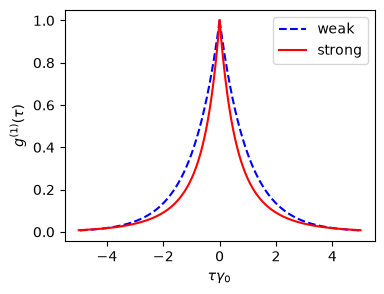

In [5]:

sz, sp, sm = spin_ops()
times = np.linspace(0, 5, 500)
theta_detect = np.pi/2
phi_detect = 0
nhat = detector_pos(theta_detect,phi_detect)
r=emitters_pos(r12)

D1=np.exp(-1j*np.inner(nhat,r[0])) * sm[0]
D2=np.exp(-1j*np.inner(nhat,r[1])) * sm[1]
D = [D1,D2]

I1 = 0
G1 = 0
for k in range(2):
    rho_0 = rho_ss*D[k].dag()
    e_ops = D[k]
    result = mesolve(H,rho_0,times,c_ops,e_ops=e_ops)
    I1 += expect(D[k].dag()*D[k],rho_ss)
    G1 += result.expect[0]

g1 = G1/I1
g1_th = np.exp(-times)
plt.figure(figsize=(4,3))
plt.plot(times,g1_th.real,color="b",ls='--',label="weak")
plt.plot(-times,g1_th.real,color="b",ls='--')
plt.plot(times,g1.real,color="r",label="strong")
plt.plot(-times,g1.real,color="r")
plt.xlabel(r"$\tau\gamma_{0}$")
plt.ylabel(r"$g^{(1)}(\tau)$")
plt.legend(loc=1)
plt.show()

## First-order coherence function (Detector Model II)

The  first-order coherence function should not depend on the detector model.  The two results are identical.

In [6]:
DD = sum(D)

# intensity
I2=expect(DD.dag()*DD,rho_ss)

rho_0 = rho_ss*DD.dag()
e_ops = DD
result = mesolve(H,rho_0,times,c_ops,e_ops=e_ops)
G1 = result.expect[0]

g1 = G1/I2
g1_weak = np.exp(-times)
plt.figure(figsize=(4,3))
plt.plot(times,g1_waek.real,color="b",ls='--',label="weak")
plt.plot(-times,g1_weak.real,color="b",ls='--')
plt.plot(times,g1.real,color="r",label="strong")
plt.plot(-times,g1.real,color="r")
plt.xlabel(r"$\tau\gamma_{0}$")
plt.ylabel(r"$g^{(1)}(\tau)$")
plt.legend(loc=1)
plt.show()

NameError: name 'g1_waek' is not defined

<Figure size 400x300 with 0 Axes>

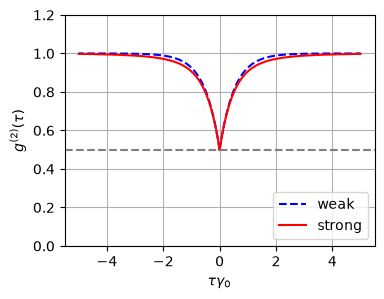

In [70]:
G2 = 0
for i in range(2):
    for j in range(2):
        
        rho_0 = D[i]*rho_ss*D[i].dag()
        e_ops = D[j].dag()*D[j]
        result = mesolve(H,rho_0,times,c_ops,e_ops=e_ops)
        G2 += result.expect[0]      

g2 = G2/I1**2
nbar0 = 1/(np.exp(omega0/T)-1)
g2_weak  = 1 - 0.5*np.exp(-(2*nbar0+1)*times)
plt.figure(figsize=(4,3))
plt.plot(times,np.real(g2_weak),c='b',ls='--',label='weak')
plt.plot(-times,np.real(g2_weak),c='b',ls='--')
plt.plot(times, np.real(g2),c='r',label='strong')
plt.plot(-times,np.real(g2),c='r')

plt.xlabel(r'$\tau\gamma_{0}$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.axhline(y=0.5,color='grey',ls='--')
plt.ylim([0,1.2])
plt.legend(loc=4)
plt.grid(True)
plt.show()


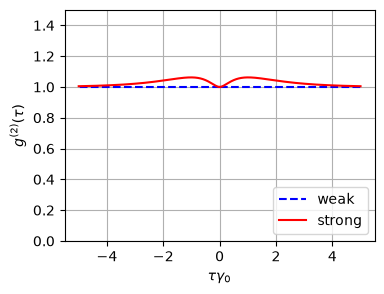

In [79]:

rho_0 = DD*rho_ss*DD.dag()
e_ops = DD.dag()*DD
result = mesolve(H,rho_0,times,c_ops,e_ops=e_ops)
G2 = result.expect[0]      

g2 = G2/I2**2
g2_weak = np.full(times.size, 1)
plt.figure(figsize=(4,3))
plt.plot(times,np.real(g2_weak),c='b',ls='--',label='weak')
plt.plot(-times,np.real(g2_weak),c='b',ls='--')
plt.plot(times, np.real(g2),c='r',label='strong')
plt.plot(-times,np.real(g2),c='r')
plt.xlabel(r'$\tau\gamma_{0}$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.legend(loc=4)
plt.ylim([0,1.5])
plt.grid(True)
plt.show()

## Coherence betweem $|ge\rangle$ and $|eg\rangle$